In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [4]:
import pandas as pd
dat=pd.read_csv('/content/CVD_Vital_SIgns.csv')
dat

,subject_id,icustay_id,heart_rate,blood_pressure,oxygen_saturation,respiratory_rate,temperature,Label
0,94297,200697.0,93.0,94.0,98.0,39.0,36.0,1
1,94229,219381.0,97.0,96.0,98.0,16.0,36.5,0
2,94195,276193.0,82.0,96.0,97.0,25.0,36.3,1
3,94256,241577.0,98.0,196.0,96.0,16.0,36.5,1
4,93996,236789.0,98.0,92.0,99.0,28.0,37.2,1
...,...,...,...,...,...,...,...,...
23463,32192,237188.0,98.0,117.0,97.0,34.0,37.5,1
23464,32673,259205.0,70.0,93.0,96.0,25.0,37.2,1
23465,32707,218238.0,86.0,91.0,97.0,27.0,36.9,1
23466,32743,246523.0,76.0,85.0,99.0,20.0,36.2,1


In [5]:
corr = dat.corr()

corr['Label'].sort_values(ascending=False)

,Label
Label,1.000000
respiratory_rate,0.467836
blood_pressure,0.135712
temperature,0.064378
oxygen_saturation,0.004756
heart_rate,0.003800
subject_id,0.003143
icustay_id,-0.000393


In [6]:
dat.isnull().sum()


,0
subject_id,0
icustay_id,0
heart_rate,0
blood_pressure,0
oxygen_saturation,0
respiratory_rate,0
temperature,0
Label,0


In [7]:
dat.describe()

,subject_id,icustay_id,heart_rate,blood_pressure,oxygen_saturation,respiratory_rate,temperature,Label
count,23468.000000,23468.000000,2.346800e+04,23468.000000,23468.000000,23468.000000,23468.000000,23468.000000
mean,62366.052114,250133.301176,5.187781e+02,104.420999,97.317978,24.711991,37.903721,0.747145
std,24233.774938,28861.410223,6.527666e+04,21.025540,62.898965,11.262183,6.918300,0.434658
min,23.000000,200001.000000,7.000000e+00,-11.000000,9.000000,2.000000,-3.000000,0.000000
25%,46995.500000,225166.750000,9.000000e+01,93.000000,96.000000,16.000000,36.800000,0.000000
50%,64336.500000,250301.000000,9.400000e+01,98.000000,97.000000,25.000000,37.200000,1.000000
75%,82072.250000,275103.250000,9.700000e+01,110.000000,98.000000,30.000000,37.800000,1.000000
max,99999.000000,299998.000000,9.999999e+06,290.000000,9560.000000,914.000000,101.300000,1.000000


In [8]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23468 entries, 0 to 23467
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         23468 non-null  int64  
 1   icustay_id         23468 non-null  float64
 2   heart_rate         23468 non-null  float64
 3   blood_pressure     23468 non-null  float64
 4   oxygen_saturation  23468 non-null  float64
 5   respiratory_rate   23468 non-null  float64
 6   temperature        23468 non-null  float64
 7   Label              23468 non-null  int64  
dtypes: float64(6), int64(2)
memory usage: 1.4 MB


In [9]:
dat.fillna(dat.median(), inplace=True)

In [10]:
import numpy as np

def remove_outliers_iqr(df, columns):
    df_clean = df.copy()

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean[col] = np.where(df_clean[col] < lower_bound, lower_bound, df_clean[col])
        df_clean[col] = np.where(df_clean[col] > upper_bound, upper_bound, df_clean[col])

    return df_clean

<Axes: >

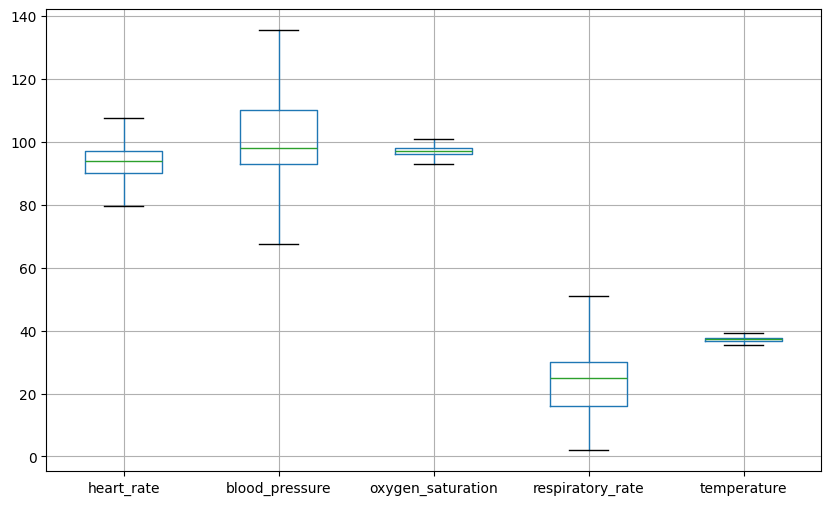

In [11]:
features = [
    'heart_rate',
    'blood_pressure',
    'oxygen_saturation',
    'respiratory_rate',
    'temperature'
]
cols_with_outliers = features
dat_clean = remove_outliers_iqr(dat, cols_with_outliers)
dat_clean[cols_with_outliers].boxplot(figsize=(10,6))

In [12]:
dat.head()

,subject_id,icustay_id,heart_rate,blood_pressure,oxygen_saturation,respiratory_rate,temperature,Label
0,94297,200697.0,93.0,94.0,98.0,39.0,36.0,1
1,94229,219381.0,97.0,96.0,98.0,16.0,36.5,0
2,94195,276193.0,82.0,96.0,97.0,25.0,36.3,1
3,94256,241577.0,98.0,196.0,96.0,16.0,36.5,1
4,93996,236789.0,98.0,92.0,99.0,28.0,37.2,1


In [13]:
dat= dat_clean[features]

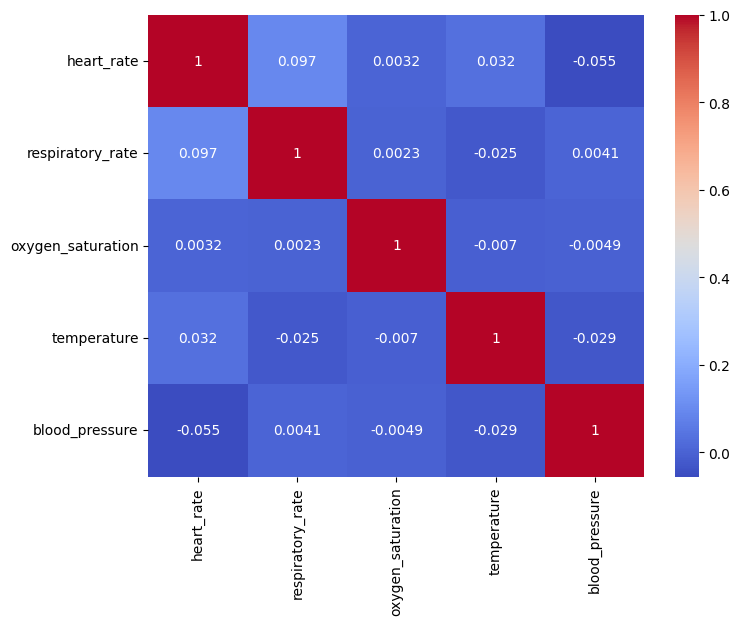

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['heart_rate','respiratory_rate','oxygen_saturation',
            'temperature','blood_pressure']

corr = dat[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

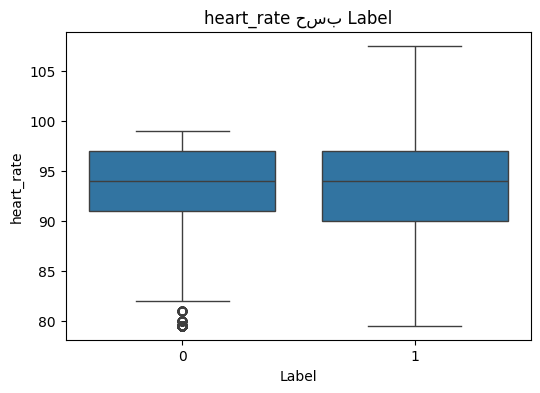

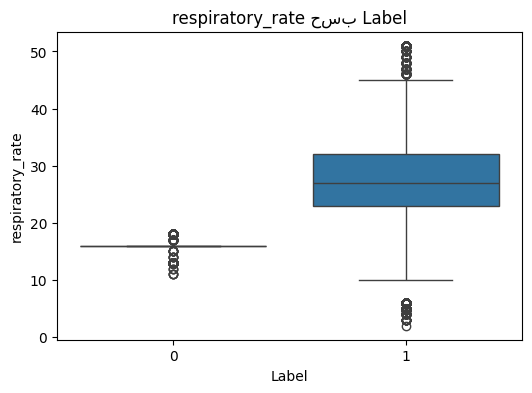

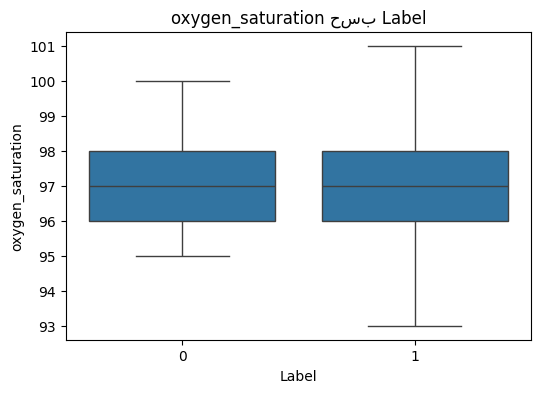

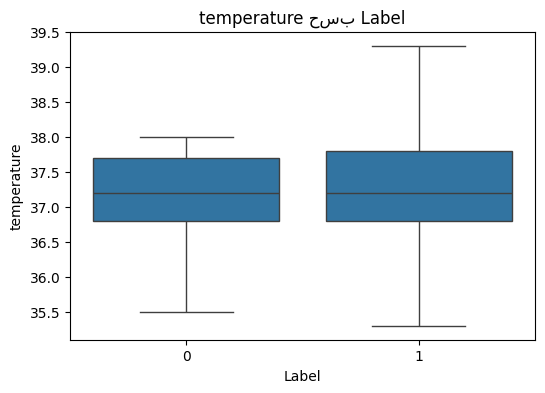

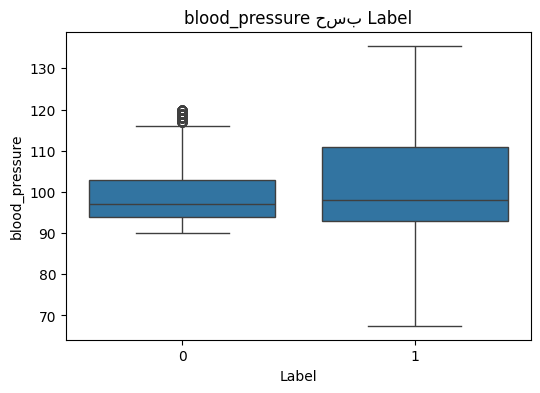

In [15]:
numeric_features = features
for feature in numeric_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Label', y=feature, data=dat_clean)
    plt.title(f"{feature} حسب Label")
    plt.show()

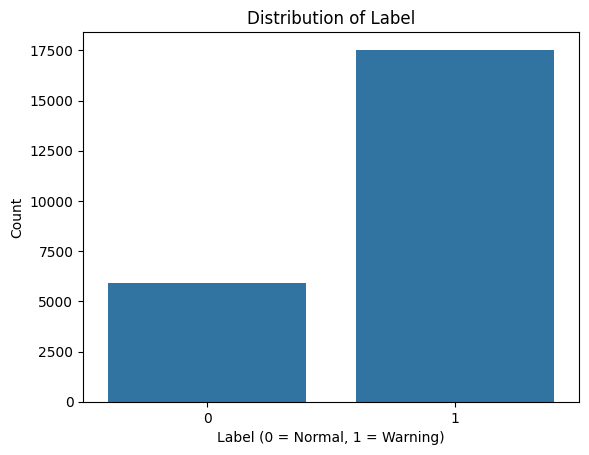

In [16]:

plt.figure()
sns.countplot(x='Label', data=dat_clean)

plt.title('Distribution of Label')
plt.xlabel('Label (0 = Normal, 1 = Warning)')
plt.ylabel('Count')

plt.show()

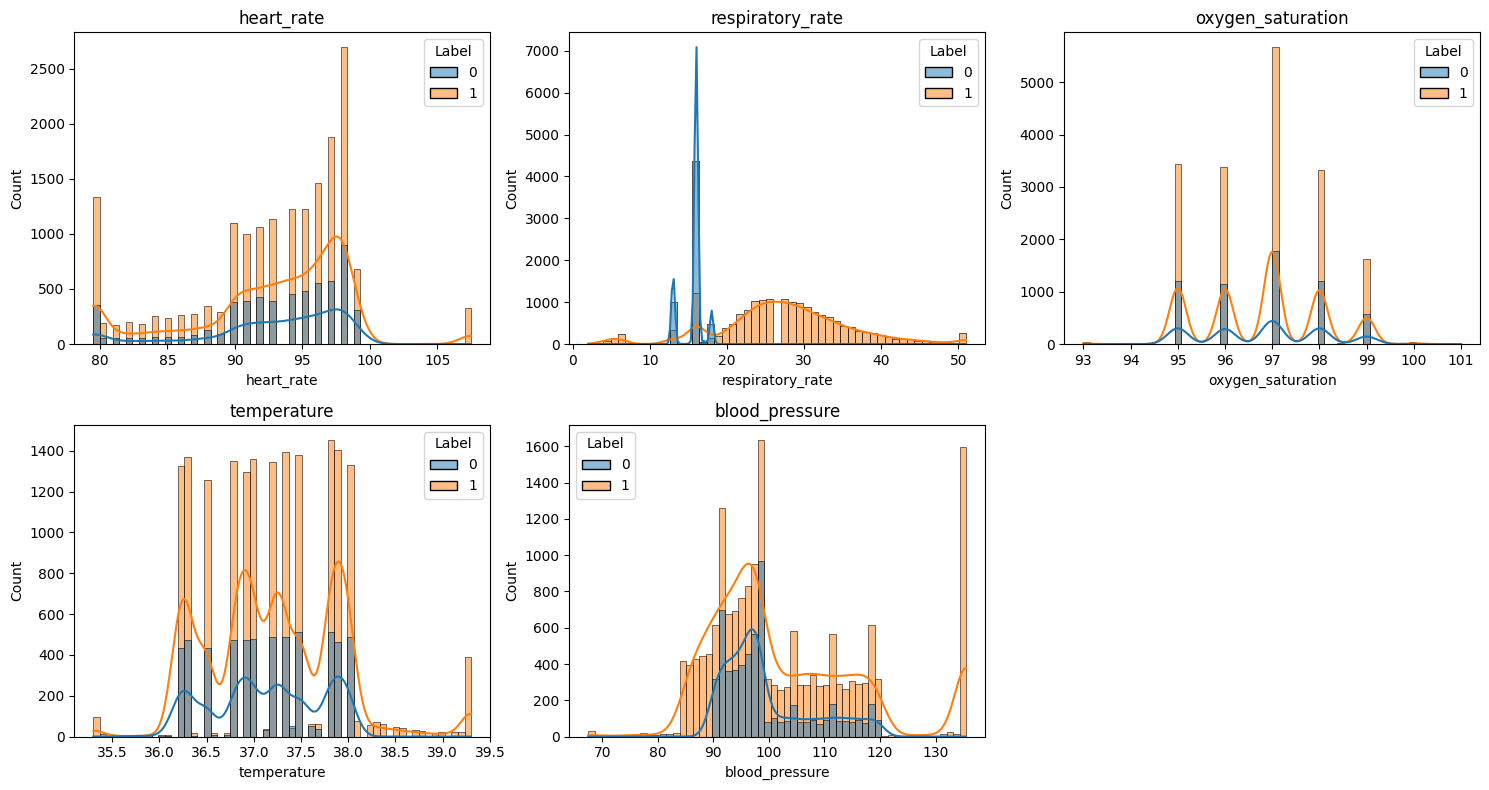

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['heart_rate','respiratory_rate','oxygen_saturation',
            'temperature','blood_pressure']


plt.figure(figsize=(15,8))

for i, col in enumerate(features,1):

    plt.subplot(2,3,i)
    sns.histplot(x=col, hue='Label', data=dat_clean, kde=True) # Changed to histplot for distribution
    plt.title(col)

plt.tight_layout()
plt.show()

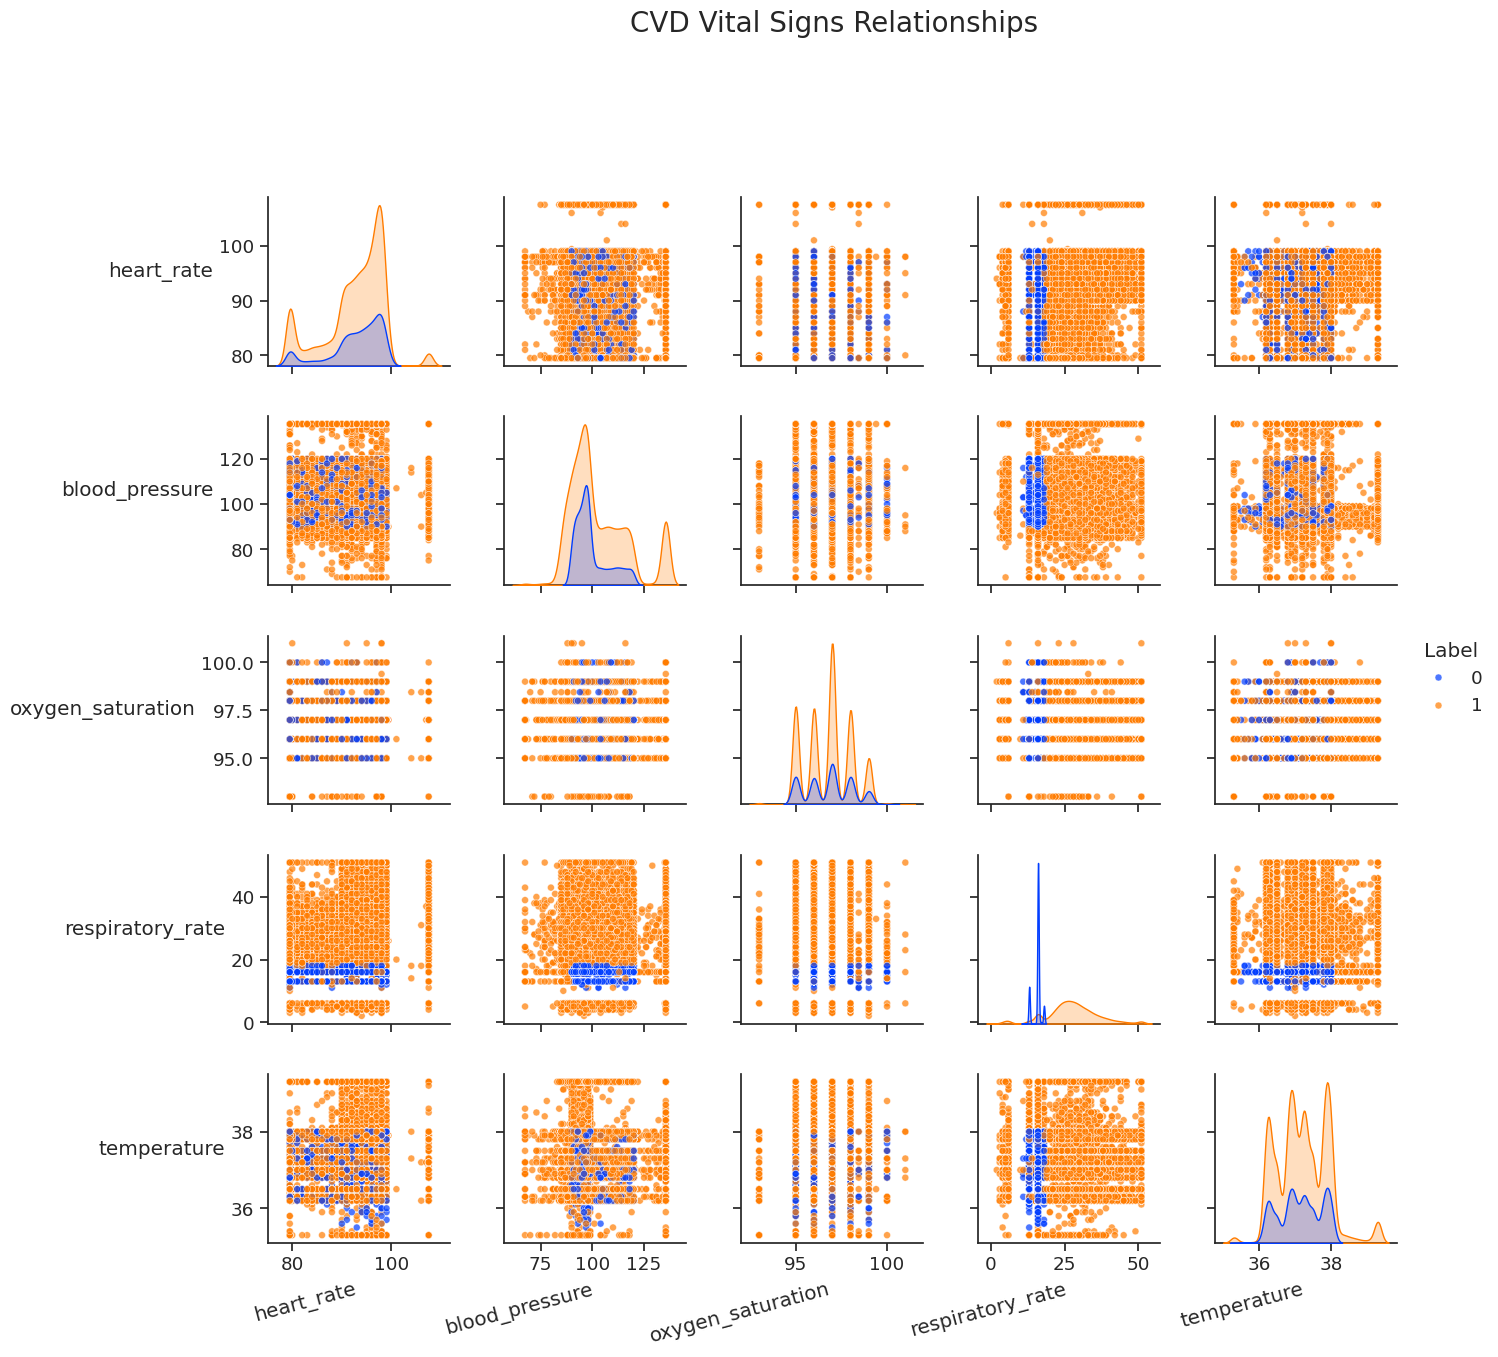

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['heart_rate', 'blood_pressure', 'oxygen_saturation', 'respiratory_rate', 'temperature']

sns.set_theme(style="ticks", font_scale=1.2)
g = sns.pairplot(dat_clean[features + ['Label']],
                 hue='Label',
                 palette='bright',
                 diag_kind='kde',
                 plot_kws={'alpha': 0.7, 's': 25})

plt.subplots_adjust(wspace=0.3, hspace=0.3, top=0.9)

g.fig.suptitle('CVD Vital Signs Relationships', fontsize=20, y=1.05)

for ax in g.axes.flat:
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), rotation=15, horizontalalignment='right')
        ax.set_ylabel(ax.get_ylabel(), rotation=0, horizontalalignment='right')

plt.show()

In [19]:
from sklearn.preprocessing import StandardScaler

X = dat
y = dat_clean['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
dat.describe()

,heart_rate,blood_pressure,oxygen_saturation,respiratory_rate,temperature
count,23468.000000,23468.000000,23468.000000,23468.000000,23468.000000
mean,92.725452,102.087523,96.793392,24.536646,37.186903
std,5.866998,12.970144,1.250918,8.898387,0.675953
min,79.500000,67.500000,93.000000,2.000000,35.300000
25%,90.000000,93.000000,96.000000,16.000000,36.800000
50%,94.000000,98.000000,97.000000,25.000000,37.200000
75%,97.000000,110.000000,98.000000,30.000000,37.800000
max,107.500000,135.500000,101.000000,51.000000,39.300000


In [21]:

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [22]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9987217724755006
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1187
           1       1.00      1.00      1.00      3507

    accuracy                           1.00      4694
   macro avg       1.00      1.00      1.00      4694
weighted avg       1.00      1.00      1.00      4694



<Figure size 800x600 with 0 Axes>

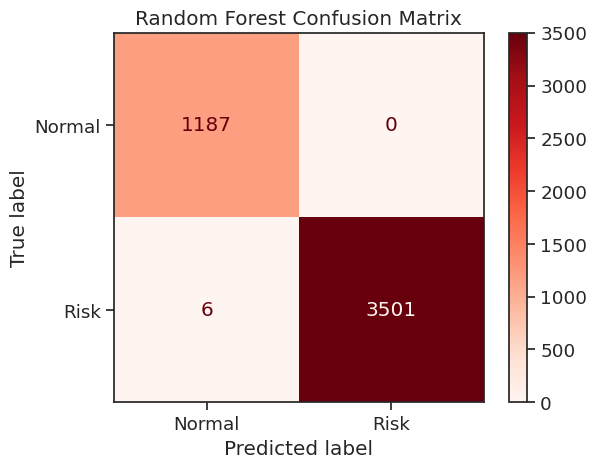

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Normal', 'Risk'])
disp_rf.plot(cmap='Reds', values_format='d')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pickle

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)


y_pred = model_rf.predict(X_test)
print("Random Forest Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")


with open("RandomForest_model_and_scaler.pkl", "wb") as f:
    pickle.dump({"model": model_rf, "scaler": scaler}, f)
print(" Random Forest")

Random Forest Metrics:
Accuracy: 0.9985
Precision: 0.9997
Recall: 0.9983
F1-score: 0.9990
 Random Forest


In [25]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_split=5, random_state=42)

In [26]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9931827865360034
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1187
           1       1.00      0.99      1.00      3507

    accuracy                           0.99      4694
   macro avg       0.99      1.00      0.99      4694
weighted avg       0.99      0.99      0.99      4694



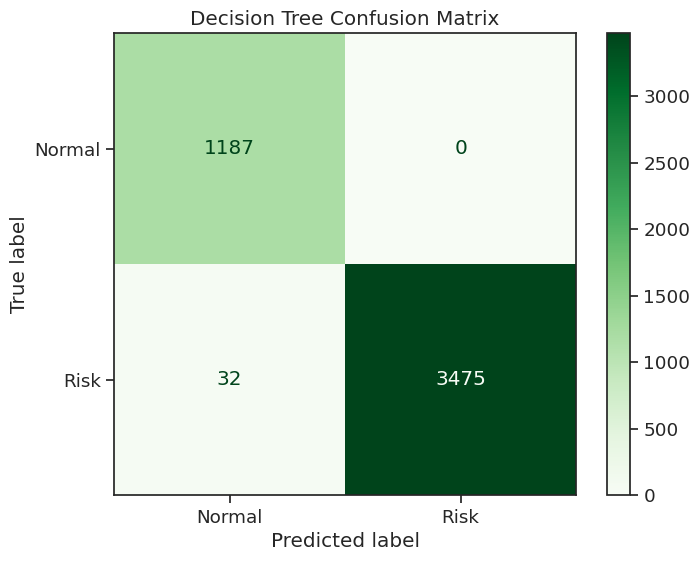

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm_dt = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Normal', 'Risk'])
disp_dt.plot(cmap='Greens', values_format='d', ax=ax)

plt.title('Decision Tree Confusion Matrix')
plt.show()

In [28]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

y_pred = model_dt.predict(X_test)
print("Decision Tree Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")

with open("DecisionTree_model_and_scaler.pkl", "wb") as f:
    pickle.dump({"model": model_dt, "scaler": scaler}, f)
print(" Decision Tree")

Decision Tree Metrics:
Accuracy: 0.9972
Precision: 0.9977
Recall: 0.9986
F1-score: 0.9981
 Decision Tree


In [29]:
import pandas as pd
import joblib

data = joblib.load("DecisionTree_model_and_scaler.pkl")

model = data['model']
scaler = data['scaler']

features = ['heart_rate', 'blood_pressure', 'oxygen_saturation', 'respiratory_rate', 'temperature']

new_data = [[80, 120, 105, 12, 36.5]]

new_df = pd.DataFrame(new_data, columns=features)

new_df_scaled = scaler.transform(new_df)

prediction = model.predict(new_df_scaled)
prediction_proba = model.predict_proba(new_df_scaled)


if prediction[0] == 1:
    print(" Risk")
else:
    print(" Normal")

 Risk


In [30]:
!pip install imbalanced-learn
!pip install xgboost

In [31]:
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

X = dat_clean[features]
y = dat_clean['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Accuracy: 0.9985087345547508

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1187
           1       1.00      1.00      1.00      3507

    accuracy                           1.00      4694
   macro avg       1.00      1.00      1.00      4694
weighted avg       1.00      1.00      1.00      4694



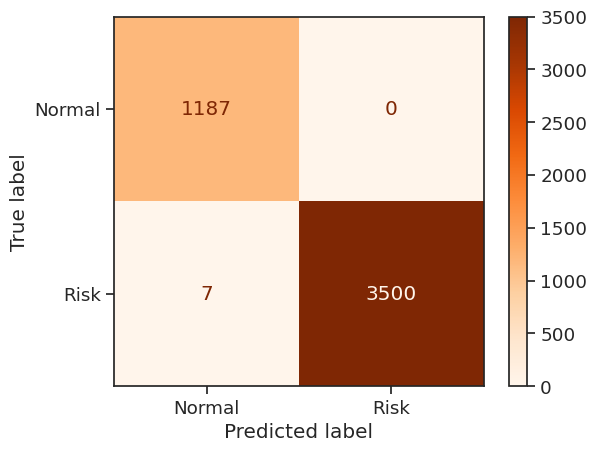

In [32]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Risk'])
disp.plot(cmap='Oranges', values_format='d')

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(" XGBoost Metrics:\n")
print(f"Accuracy  : {accuracy*100:.4f}%")
print(f"Precision : {precision*100:.4f}%")
print(f"Recall    : {recall*100:.4f}%")
print(f"F1-Score  : {f1*100:.4f}%")

 XGBoost Metrics:

Accuracy  : 99.8509%
Precision : 100.0000%
Recall    : 99.8004%
F1-Score  : 99.9001%


In [34]:
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("XGBoost")

XGBoost


In [46]:

!pip install catboost

In [70]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report


model_cb = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=5,
    random_seed=42,
    verbose=0
)

model_cb.fit(X_train, y_train)

y_pred_cb = model_cb.predict(X_test)

In [72]:
import pickle

with open("CatBoost_model_and_scaler.pkl", "wb") as f:
    pickle.dump({"model": model_cb, "scaler": scaler}, f)

print("CatBoost ")

CatBoost 


In [74]:
import joblib
import shap

data = joblib.load("CatBoost_model_and_scaler.pkl")
model = data['model']
scaler = data['scaler']

explainer = shap.TreeExplainer(model)

In [64]:
print("CatBoost Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_cb):.4f}")
print(classification_report(y_test, y_pred_cb))

CatBoost Metrics:
Accuracy: 0.9987
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1187
           1       1.00      1.00      1.00      3507

    accuracy                           1.00      4694
   macro avg       1.00      1.00      1.00      4694
weighted avg       1.00      1.00      1.00      4694



<Figure size 800x600 with 0 Axes>

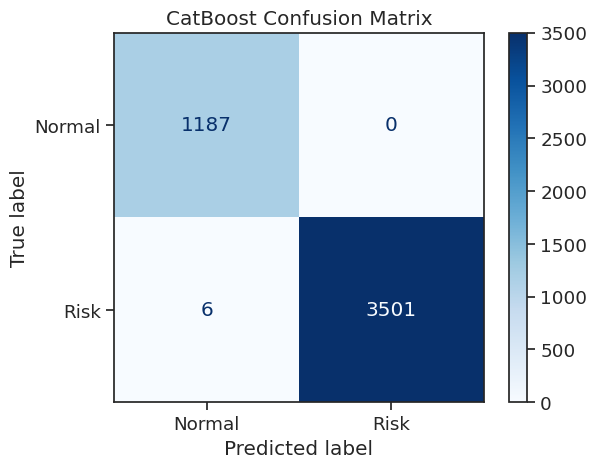

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred_cb)


plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Risk'])
disp.plot(cmap='Blues')
plt.title('CatBoost Confusion Matrix')
plt.show()



In [39]:

print(f"CatBoost Accuracy: {accuracy_score(y_test, y_pred_cb)*100:.2f}%")
print(f"CatBoost Precision: {precision_score(y_test, y_pred_cb)*100:.2f}%")
print(f"CatBoost Recall: {recall_score(y_test, y_pred_cb)*100:.2f}%")
print(f"CatBoost F1-Score: {f1_score(y_test, y_pred_cb)*100:.2f}%")

CatBoost Accuracy: 99.87%
CatBoost Precision: 100.00%
CatBoost Recall: 99.83%
CatBoost F1-Score: 99.91%


In [40]:
import lightgbm as lgb
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

model_lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

model_lgbm.fit(X_train, y_train)


y_pred_lgbm = model_lgbm.predict(X_test)

[LightGBM] [Info] Number of positive: 14027, number of negative: 4747
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006792 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 189
[LightGBM] [Info] Number of data points in the train set: 18774, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [41]:

print("--- LightGBM Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lgbm):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lgbm):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lgbm):.4f}")




--- LightGBM Metrics ---
Accuracy:  0.9985
Precision: 0.9997
Recall:    0.9983
F1-Score:  0.9990


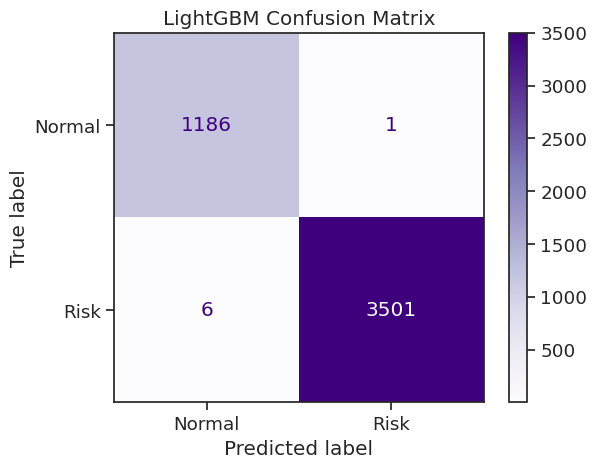

In [42]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
disp_lgbm = ConfusionMatrixDisplay(confusion_matrix=cm_lgbm, display_labels=['Normal', 'Risk'])
disp_lgbm.plot(cmap='Purples', values_format='d')
plt.title('LightGBM Confusion Matrix')
plt.show()

In [43]:
import pickle


with open("LGBM_model_and_scaler.pkl", "wb") as f:
    pickle.dump({"model": model_lgbm, "scaler": scaler}, f)

print("LightGBM Model ")

LightGBM Model 
